# Smart Posture Corrector

Tugas Besar IF4051 IOT

- Tazkia Nizami - 13522032
- Bagas Sambega Rosyada - 13522071
- Raden Francisco Trianto Bratadiningrat - 13522091


.

### Main Problem: Predict Bad Posture From MPU6050 Data

## Table Of Contents
1. [Setup](#scrollTo=XcypJ4J5dlhx)
2. [Load Data](#scrollTo=WlqK9MDVdHrZ)
3. [Data Analysis & EDA](#scrollTo=ph95ZI4bqVrH)
4. [Preprocessing](#scrollTo=AK3g--GW-Fhg)
5. [Split Data (train/test)](#scrollTo=CZGNZpj3A6Je)
6. [Baseline Model](#scrollTo=5iIToSzB-SV-)
7. [Hypotheses & Feature Engineering](#scrollTo=R8NJkJhXR92H)
8. [Export Model](#scrollTo=b6HT1HsD-YIA)

## 1 - Setup



### 1.1 Install Extra Dependencies

In [1]:
%pip install pandas numpy scipy scikit-learn matplotlib seaborn requests xgboost lightgbm catboost scikeras tensorflow jinja2 keras micromlgen emlearn m2cgen

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 9.6 MB/s eta 0:00:00
  Created wheel for micromlgen: filename=micromlgen-1.1.28-py3-none-any.whl size=32152 sha256=637499a9a3873560cf7836c24fe935751a9d675acb840aa13575ccca74124351
  Stored in directory: /root/.cache/pip/wheels/16/02/8a/3a8b533174e4f7691a8fd72dab4493fb6819b79f8fcc1d18a6
Successfully built micromlgen


### 1.2 Import Modules

In [2]:
# Load Data
from google.colab import drive
from pathlib import Path

# Calc and Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_theme(style="whitegrid", palette="tab20")

# Data and Modeling
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scikeras.wrappers import KerasClassifier
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers

# Size Estimation & Model Export
import os
import joblib
import tempfile
import json
import emlearn
from micromlgen import port
import m2cgen as m2c

# Set Seed
np.random.seed(42)
tf.random.set_seed(42)


## 2 - Load Data


### 2.1. Mount Drive

In [4]:
# Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2.2. Set & Check File Path

In [7]:
%cd "/content/drive/MyDrive/CGI/IOT"

# ADJUST THIS TO YOUR DRIVE

/content/drive/MyDrive/CGI/IOT


In [57]:
PATH = Path.cwd() / "input"
OUTPUT_PATH = Path.cwd() / "output_labeled_en"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

files = {
    "bb1": PATH / "berdiri_bungkuk.csv",
    "bb2": PATH / "berdiri_bungkuk_v2.csv",
    "bt1": PATH / "berdiri_tegak.csv",
    "bt2": PATH / "berdiri_tegak_v2.csv",
    "db1": PATH / "duduk_bungkuk.csv",
    "db2": PATH / "duduk_bungkuk_v2.csv",
    "dt1": PATH / "duduk_tegak.csv",
    "dt2": PATH / "duduk_tegak_v2.csv",
    "jt": PATH / "jalan_tegak.csv",
    "jb": PATH / "jalan_bungkuk.csv",
    "jt2": PATH / "jalan_tegak_taz.csv",
    "jb2": PATH / "jalan_bungkuk_taz.csv",
    "combined": PATH / "dataset_all_english.csv",
}

missing = {name: path for name, path in files.items() if not path.exists()}

if not missing:
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")
    for name, path in missing.items():
        print(f"- {name}: {path}")

All files exist and path is correctly set.


In [54]:
label_id_to_en = {
    "berdiri_tegak": "standing_upright",
    "berdiri_bungkuk": "standing_slouched",
    "duduk_tegak": "sitting_upright",
    "duduk_bungkuk": "sitting_slouched",
    "duduk_kursi_tegak": "chair_sitting_upright",
    "duduk_kursi_bungkuk": "chair_sitting_slouched",
    "duduk_lantai_tegak": "floor_sitting_upright",
    "duduk_lantai_bungkuk": "floor_sitting_slouched",
    "jalan_tegak": "walking_upright",
    "jalan_bungkuk": "walking_slouched",
    "transisi_duduk_ke_berdiri_kursi": "transition_chair_sit_to_stand",
    "transisi_berdiri_ke_duduk_kursi": "transition_stand_to_chair_sit",
    "transisi_duduk_ke_berdiri_lantai": "transition_floor_sit_to_stand",
    "transisi_berdiri_ke_duduk_lantai": "transition_stand_to_floor_sit",
}

file_to_label_id = {
    "berdiri_bungkuk": "berdiri_bungkuk",
    "berdiri_bungkuk_v2": "berdiri_bungkuk",
    "berdiri_tegak": "berdiri_tegak",
    "berdiri_tegak_v2": "berdiri_tegak",
    "duduk_bungkuk": "duduk_bungkuk",
    "duduk_bungkuk_v2": "duduk_bungkuk",
    "duduk_tegak": "duduk_tegak",
    "duduk_tegak_v2": "duduk_tegak",
    "jalan_tegak": "jalan_tegak",
    "jalan_bungkuk": "jalan_bungkuk",
    "jalan_tegak_taz": "jalan_tegak",
    "jalan_bungkuk_taz": "jalan_bungkuk",
}

Combined all data into one dataset and convert label to english

In [55]:
# def find_label_column(df):
#     candidates = ["label", "Label", "class", "Class", "kategori", "posture", "target"]
#     for col in candidates:
#         if col in df.columns:
#             return col
#     return None

# report = []
# relabeled_dfs = []

# for short_name, path in files.items():
#     if not path.exists():
#         continue

#     df = pd.read_csv(path)
#     stem = path.stem

#     if stem not in file_to_label_id:
#         report.append({
#             "file": path.name,
#             "status": "SKIPPED",
#             "reason": f"stem '{stem}' not found in file_to_label_id"
#         })
#         continue

#     expected_label_id = file_to_label_id[stem]
#     expected_label_en = label_id_to_en[expected_label_id]

#     label_col = find_label_column(df)

#     if label_col is None:
#         df["label"] = expected_label_en
#         save_path = OUTPUT_PATH / path.name
#         df.to_csv(save_path, index=False)

#         report.append({
#             "file": path.name,
#             "status": "SAVED",
#             "label_column": "created: label",
#             "expected_id": expected_label_id,
#             "saved_label": expected_label_en,
#             "reason": "No label column found, created new English label column"
#         })
#         relabeled_dfs.append(df)
#         continue

#     current_labels = (
#         df[label_col]
#         .dropna()
#         .astype(str)
#         .str.strip()
#         .str.lower()
#         .unique()
#         .tolist()
#     )

#     allowed_variants = {
#         expected_label_id.lower(),
#         expected_label_en.lower()
#     }

#     unknown_or_misaligned = [x for x in current_labels if x not in allowed_variants]

#     if len(current_labels) == 0:
#         df[label_col] = expected_label_en
#         save_path = OUTPUT_PATH / path.name
#         df.to_csv(save_path, index=False)

#         report.append({
#             "file": path.name,
#             "status": "SAVED",
#             "label_column": label_col,
#             "expected_id": expected_label_id,
#             "saved_label": expected_label_en,
#             "reason": "Label column existed but values were empty"
#         })
#         relabeled_dfs.append(df)

#     elif not unknown_or_misaligned:
#         df[label_col] = expected_label_en
#         save_path = OUTPUT_PATH / path.name
#         df.to_csv(save_path, index=False)

#         report.append({
#             "file": path.name,
#             "status": "SAVED",
#             "label_column": label_col,
#             "expected_id": expected_label_id,
#             "saved_label": expected_label_en,
#             "reason": f"Aligned labels found: {current_labels}"
#         })
#         relabeled_dfs.append(df)

#     else:
#         report.append({
#             "file": path.name,
#             "status": "REVIEW",
#             "label_column": label_col,
#             "expected_id": expected_label_id,
#             "saved_label": None,
#             "reason": f"Found misaligned labels: {current_labels}"
#         })

# report_df = pd.DataFrame(report)
# report_df

,file,status,label_column,expected_id,saved_label,reason
0,berdiri_bungkuk.csv,SAVED,label,berdiri_bungkuk,standing_slouched,Aligned labels found: ['berdiri_bungkuk']
1,berdiri_bungkuk_v2.csv,SAVED,label,berdiri_bungkuk,standing_slouched,Aligned labels found: ['berdiri_bungkuk']
2,berdiri_tegak.csv,SAVED,label,berdiri_tegak,standing_upright,Aligned labels found: ['berdiri_tegak']
3,berdiri_tegak_v2.csv,SAVED,label,berdiri_tegak,standing_upright,Aligned labels found: ['berdiri_tegak']
4,duduk_bungkuk.csv,SAVED,label,duduk_bungkuk,sitting_slouched,Aligned labels found: ['duduk_bungkuk']
5,duduk_bungkuk_v2.csv,SAVED,label,duduk_bungkuk,sitting_slouched,Aligned labels found: ['duduk_bungkuk']
6,duduk_tegak.csv,SAVED,label,duduk_tegak,sitting_upright,Aligned labels found: ['duduk_tegak']
7,duduk_tegak_v2.csv,SAVED,label,duduk_tegak,sitting_upright,Aligned labels found: ['duduk_tegak']
8,jalan_tegak.csv,SAVED,label,jalan_tegak,walking_upright,Aligned labels found: ['jalan_tegak']
9,jalan_bungkuk.csv,SAVED,label,jalan_bungkuk,walking_slouched,Aligned labels found: ['jalan_bungkuk']


In [56]:
# if relabeled_dfs:
#     df_all_en = pd.concat(relabeled_dfs, ignore_index=True)
#     combined_path = OUTPUT_PATH / "dataset_all_english.csv"
#     df_all_en.to_csv(combined_path, index=False)
#     print(f"Combined English dataset saved to: {combined_path}")
# else:
#     print("No relabeled files were combined.")

Combined English dataset saved to: /content/drive/MyDrive/CGI/IOT/output_labeled_en/dataset_all_english.csv


### 2.3. Data Overview

Simple Overview before EDA.

#### 2.3.1. Read Data


In [64]:
df_all = pd.read_csv(files["combined"])
df_all

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ,label
0,87033,-10128,120,13128,659,-28,99,0.52,37.65,4.35,40.47,-3.83,-2.83,579.51,-220.87,124.09,0.61,1.47,-0.19,standing_slouched
1,87237,-10132,696,13216,367,-71,-255,3.01,37.44,4.35,40.47,-1.34,-3.04,579.51,-220.87,124.09,-1.62,1.14,-2.89,standing_slouched
2,87440,-10188,404,12992,514,-211,-310,1.78,38.09,4.35,40.47,-2.57,-2.38,579.51,-220.87,124.09,-0.50,0.08,-3.31,standing_slouched
3,87641,-10140,-264,13032,448,-229,341,-1.16,37.88,4.35,40.47,-5.51,-2.59,579.51,-220.87,124.09,-1.00,-0.06,1.66,standing_slouched
4,87845,-10512,232,12592,886,153,92,1.06,39.85,4.35,40.47,-3.29,-0.62,579.51,-220.87,124.09,2.34,2.85,-0.24,standing_slouched
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45769,3198335,-4224,-2292,-15716,4681,350,-2358,-171.70,14.89,-172.98,65.66,1.28,-50.77,514.03,-233.62,33.35,31.81,4.46,-18.25,walking_slouched
45770,3198539,-2480,-1132,-16236,-251,97,-730,-176.01,8.66,-172.98,65.66,-3.03,-57.00,514.03,-233.62,33.35,-5.84,2.52,-5.83,walking_slouched
45771,3198743,-1872,-5932,-12280,772,-1222,572,-154.22,7.82,-172.98,65.66,18.76,-57.84,514.03,-233.62,33.35,1.97,-7.54,4.11,walking_slouched
45772,3198947,-2228,-5712,-16924,-16,-622,571,-161.35,7.11,-172.98,65.66,11.63,-58.55,514.03,-233.62,33.35,-4.05,-2.96,4.10,walking_slouched


#### 2.3.2. Data Size
Check the data size: Row x Columns

In [65]:
print('Data:', df_all.shape)

Data: (45774, 20)


#### 2.3.3. Data View

Some Sample.

In [66]:
df_all.head()

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ,label
0,87033,-10128,120,13128,659,-28,99,0.52,37.65,4.35,40.47,-3.83,-2.83,579.51,-220.87,124.09,0.61,1.47,-0.19,standing_slouched
1,87237,-10132,696,13216,367,-71,-255,3.01,37.44,4.35,40.47,-1.34,-3.04,579.51,-220.87,124.09,-1.62,1.14,-2.89,standing_slouched
2,87440,-10188,404,12992,514,-211,-310,1.78,38.09,4.35,40.47,-2.57,-2.38,579.51,-220.87,124.09,-0.50,0.08,-3.31,standing_slouched
3,87641,-10140,-264,13032,448,-229,341,-1.16,37.88,4.35,40.47,-5.51,-2.59,579.51,-220.87,124.09,-1.00,-0.06,1.66,standing_slouched
4,87845,-10512,232,12592,886,153,92,1.06,39.85,4.35,40.47,-3.29,-0.62,579.51,-220.87,124.09,2.34,2.85,-0.24,standing_slouched


#### 2.3.4. Data Info

Data types, non-null counts, and memory usage

In [67]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45774 entries, 0 to 45773
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          45774 non-null  int64  
 1   rawAccX            45774 non-null  int64  
 2   rawAccY            45774 non-null  int64  
 3   rawAccZ            45774 non-null  int64  
 4   rawGyroX           45774 non-null  int64  
 5   rawGyroY           45774 non-null  int64  
 6   rawGyroZ           45774 non-null  int64  
 7   rawKemiringanX     45774 non-null  float64
 8   rawKemiringanY     45774 non-null  float64
 9   offsetKemiringanX  45774 non-null  float64
 10  offsetKemiringanY  45774 non-null  float64
 11  kemiringanX        45774 non-null  float64
 12  kemiringanY        45774 non-null  float64
 13  gyroOffsetX        45774 non-null  float64
 14  gyroOffsetY        45774 non-null  float64
 15  gyroOffsetZ        45774 non-null  float64
 16  kecepatanRotasiX   457

#### 2.3.5. Numerical Data Summary

Count, Mean, STD (Standard Deviation), Min, Max.

In [68]:
df_all.describe()

,timestamp,rawAccX,rawAccY,rawAccZ,rawGyroX,rawGyroY,rawGyroZ,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY,kemiringanX,kemiringanY,gyroOffsetX,gyroOffsetY,gyroOffsetZ,kecepatanRotasiX,kecepatanRotasiY,kecepatanRotasiZ
count,4.577400e+04,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000,45774.000000
mean,1.970860e+06,-12031.244637,-908.878927,677.213877,577.753463,-189.066544,81.761895,-22.207889,54.726688,-42.059069,63.780236,19.849948,-9.055264,811.998028,-256.077042,125.587186,-1.788142,0.511514,-0.334569
std,1.044940e+06,3931.873767,2018.667505,9529.284316,2248.310100,1226.601424,1657.039489,117.072321,22.489287,120.061777,14.377191,105.592440,18.945366,740.321301,149.937395,201.678931,18.084765,9.421533,12.749106
min,8.703300e+04,-32768.000000,-14284.000000,-28804.000000,-21666.000000,-11851.000000,-23621.000000,-179.980000,-68.600000,-172.980000,33.480000,-358.310000,-134.260000,424.920000,-636.780000,-13.940000,-170.390000,-89.050000,-180.570000
25%,1.066116e+06,-15040.000000,-1896.000000,-6684.000000,435.000000,-308.000000,-9.000000,-151.940000,39.770000,-168.980000,56.510000,-4.280000,-16.130000,514.030000,-297.810000,33.350000,-2.660000,-0.580000,-1.370000
50%,2.014322e+06,-13456.000000,-768.000000,-786.000000,537.000000,-201.000000,58.000000,-7.360000,60.690000,-5.570000,64.680000,0.800000,-4.960000,566.030000,-233.620000,64.860000,-0.210000,0.410000,-0.110000
75%,2.856454e+06,-10516.000000,332.000000,10156.000000,642.000000,-93.000000,134.000000,5.735000,73.430000,4.350000,75.280000,15.840000,0.440000,603.610000,-185.460000,124.090000,0.670000,2.290000,0.660000
max,3.984107e+06,7428.000000,12456.000000,20520.000000,25371.000000,19867.000000,24054.000000,180.000000,89.710000,178.340000,85.210000,352.980000,51.690000,3309.160000,-35.070000,799.470000,188.680000,153.440000,183.360000


#### 2.3.6. Data Duplicate Check
Check if there is any duplicate data.

In [69]:
print(f"Duplicate rows in Train: {df_all.duplicated().sum()}")

Duplicate rows in Train: 1


## 3 - Data Analysis & EDA

### 3.1. Define label and features

In [70]:
label_column = 'label'

numerical_columns = df_all.select_dtypes(include=['number']).columns

categorical_columns = df_all.columns.drop(numerical_columns)

print("Label Columns: ", label_column)
print("\nNumerical Columns:\n", numerical_columns)
print("\nCategorical Columns:\n", categorical_columns)

Label Columns:  label

Numerical Columns:
 Index(['timestamp', 'rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY',
       'rawGyroZ', 'rawKemiringanX', 'rawKemiringanY', 'offsetKemiringanX',
       'offsetKemiringanY', 'kemiringanX', 'kemiringanY', 'gyroOffsetX',
       'gyroOffsetY', 'gyroOffsetZ', 'kecepatanRotasiX', 'kecepatanRotasiY',
       'kecepatanRotasiZ'],
      dtype='object')

Categorical Columns:
 Index(['label'], dtype='object')


### 3.2. Checking Missing Values

In [71]:
missing_values = pd.DataFrame({
    'Count': df_all.isnull().sum(),
    'Percent': (df_all.isnull().sum() / len(df_all)) * 100
})

missing_values = missing_values[missing_values['Count'] > 0].sort_values('Count', ascending=False).T

print("Amount of Features with missing Values:", missing_values.shape[1])

Amount of Features with missing Values: 0


### 3.3. Visualization and Analysis

#### 3.3.1. Label Distribution

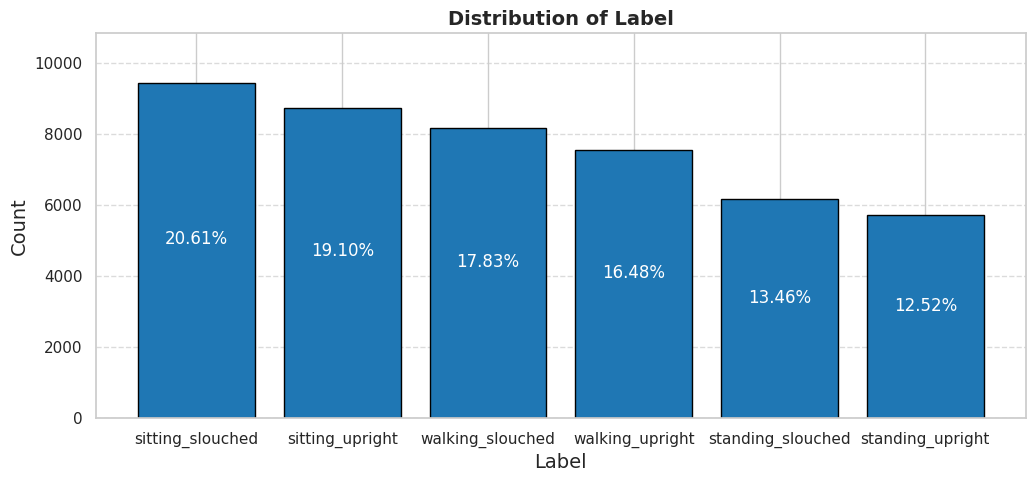

In [72]:
label_counts = df_all[label_column].value_counts()
total = len(df_all)

plt.figure(figsize=(12, 5))
bars = plt.bar(label_counts.index.astype(str), label_counts.values, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height/2 + (height * 0.01), f'{percentage:.2f}%', ha='center', va='bottom', fontsize=12, color="white")

plt.title('Distribution of Label', fontsize=14, fontweight="bold")
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.ylim(0, max(label_counts.values) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Label shows an non uniform distribution.

#### 3.3.2. Numerical Distribution

##### 3.3.2.1. Distribution

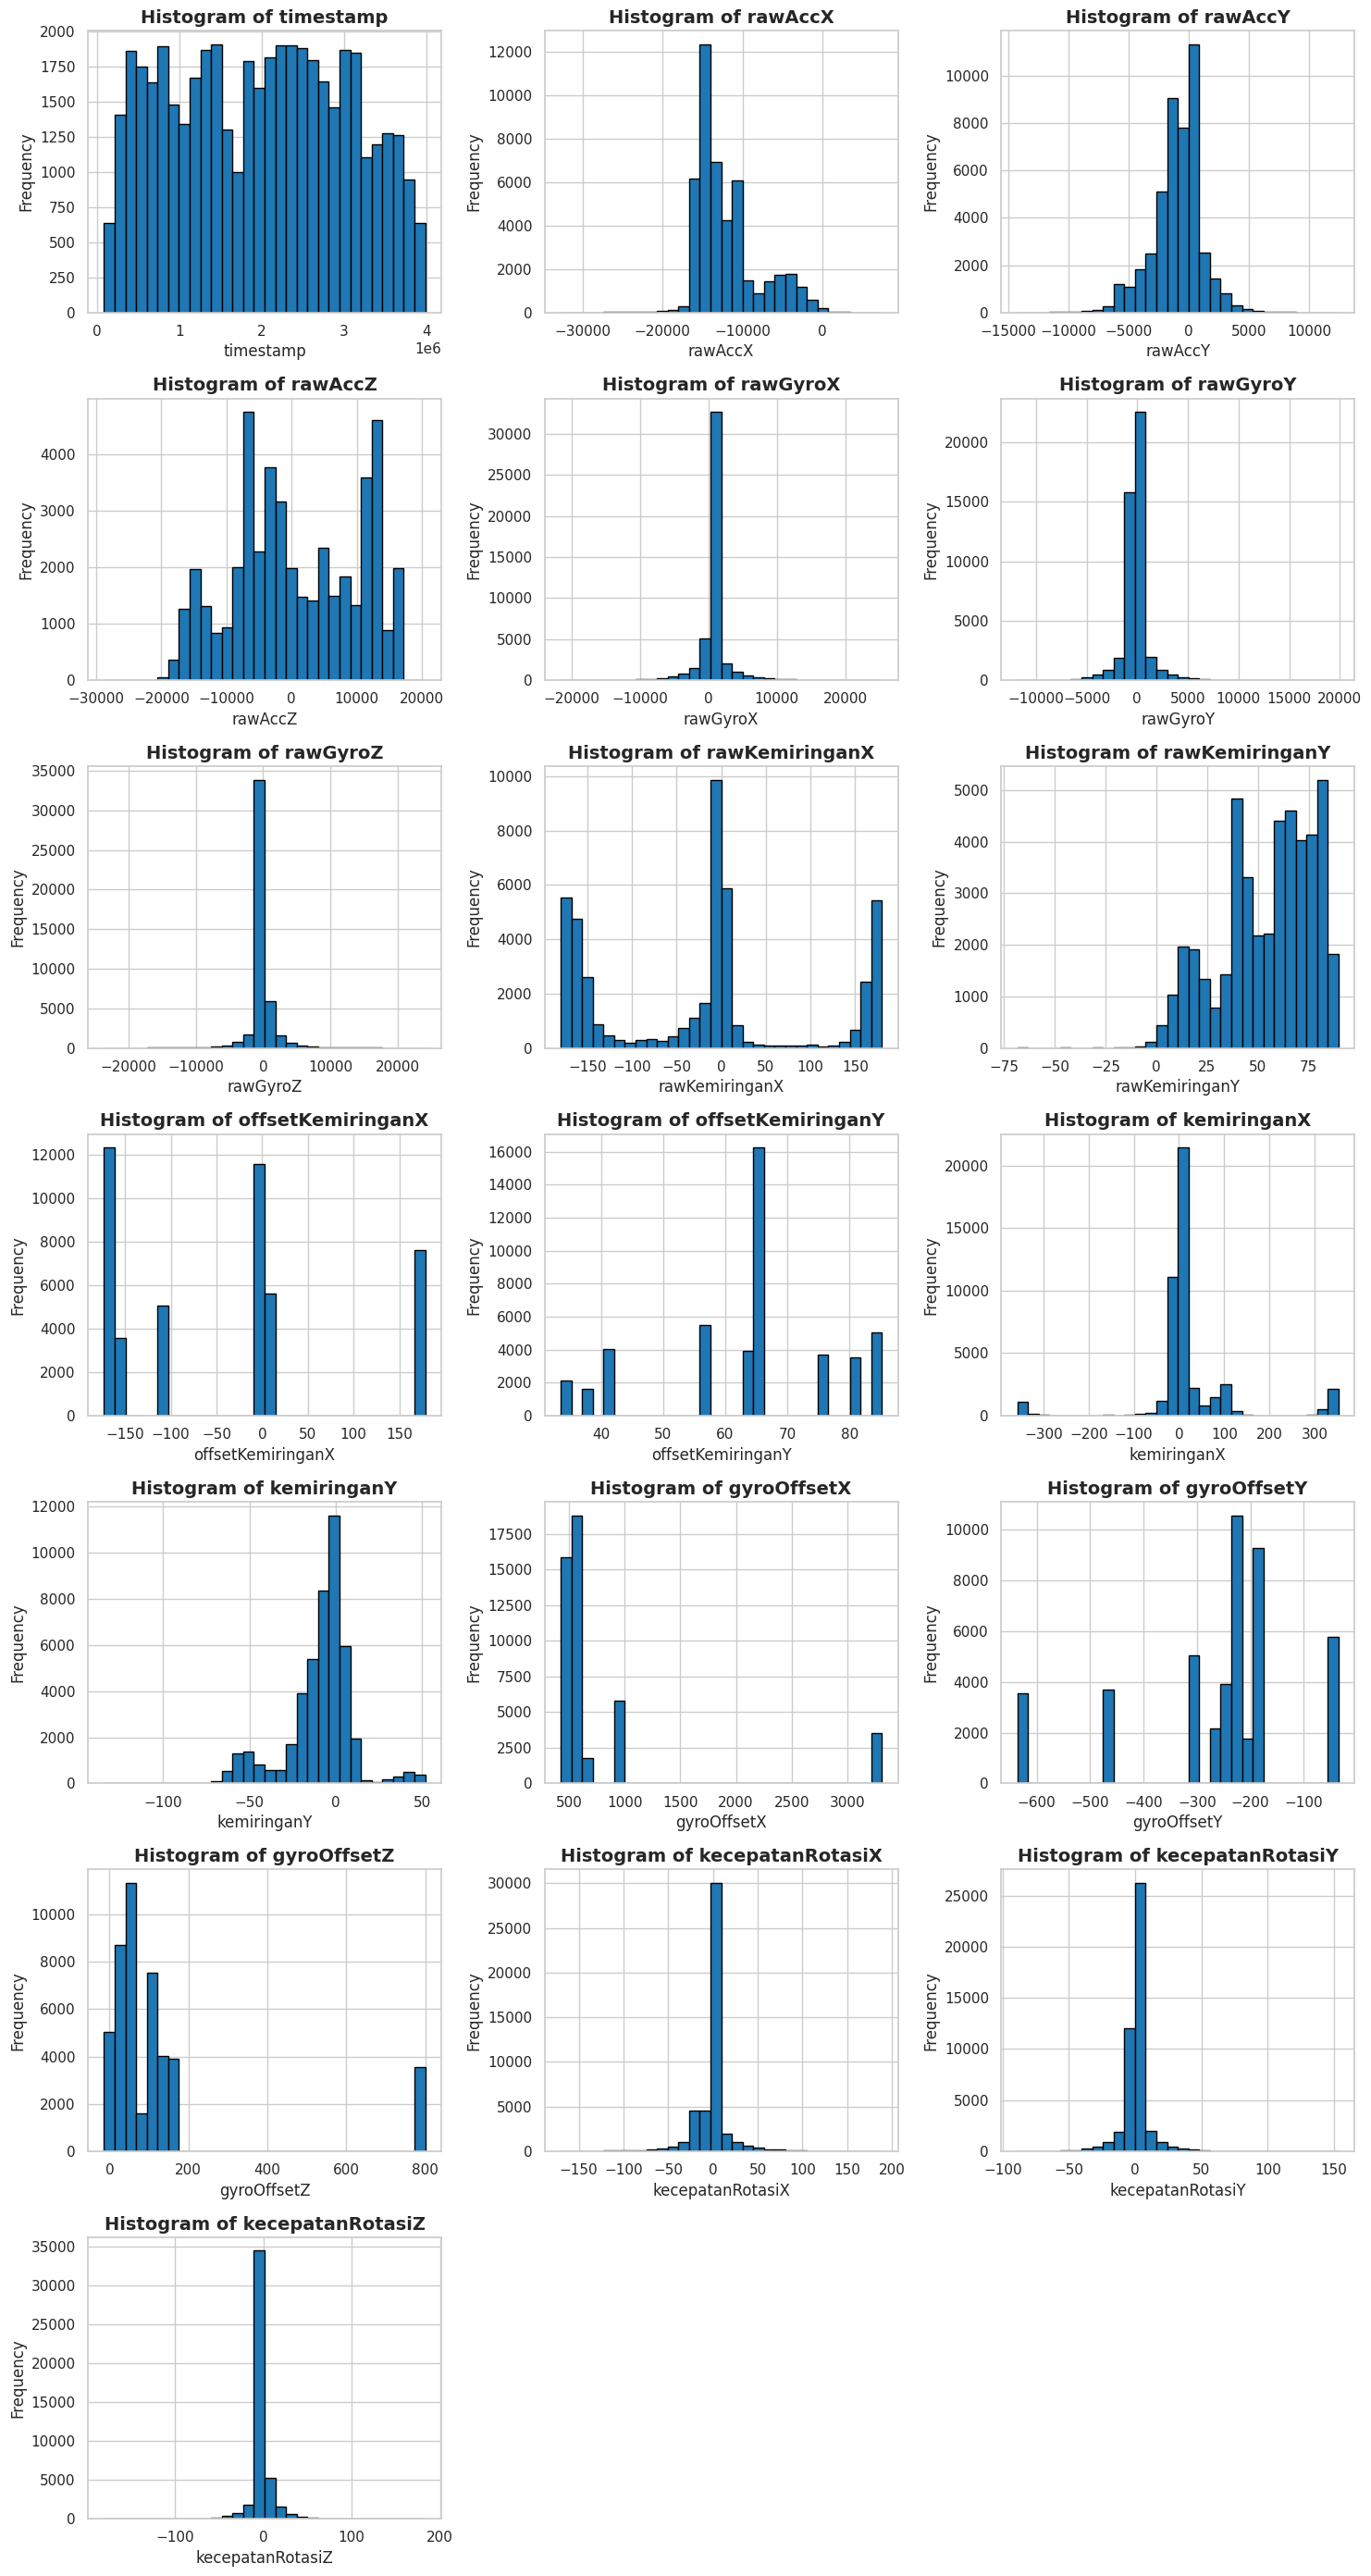

In [73]:
numerical_columns = df_all.select_dtypes(include=['number']).columns
num_cols = len(numerical_columns)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df_all[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### 3.3.2.2. Feature Correlation


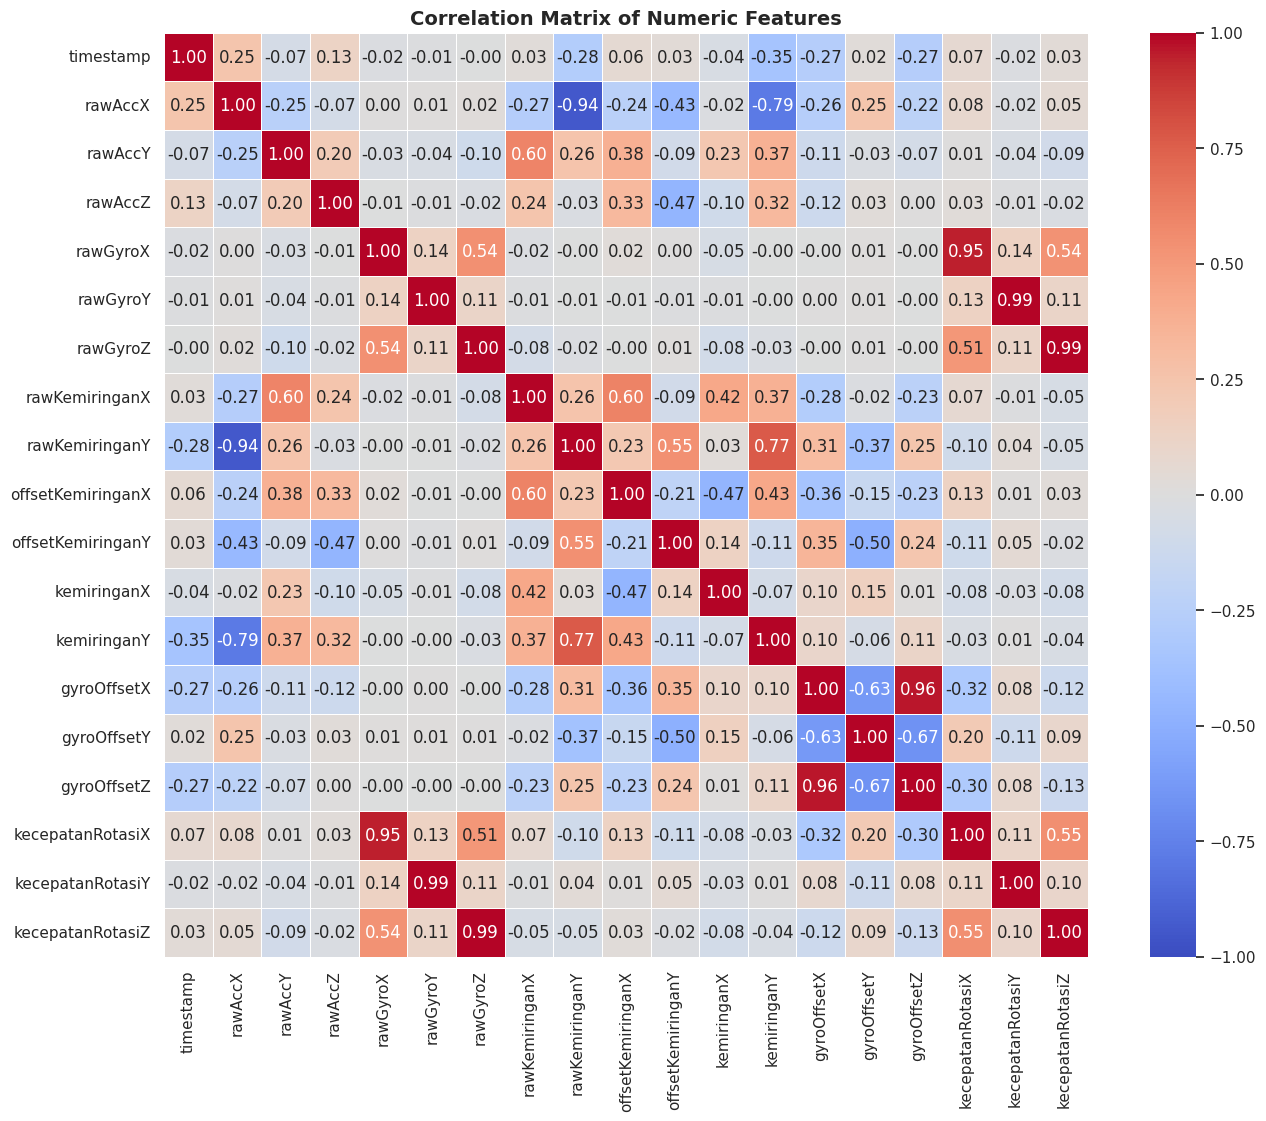

In [74]:
numeric_cols = df_all.select_dtypes(include=['number'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.show()

##### 3.3.2.3. Timestamp Feature Analysis

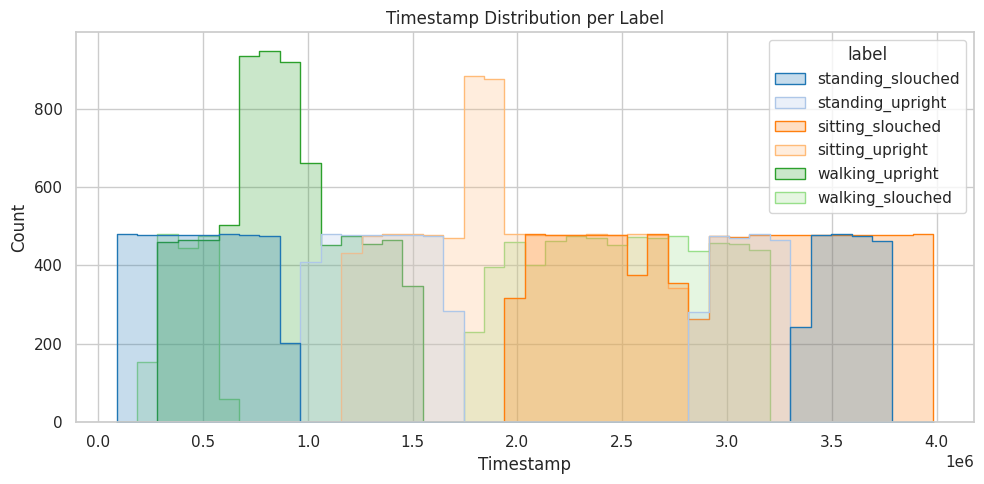

In [75]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_all, x='timestamp', hue='label', bins=40, element='step', stat='count')
plt.title('Timestamp Distribution per Label')
plt.xlabel('Timestamp')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

We can conclude that the timestamp cannot be used as it.

It could cause overfitting due to the non overlapping timestamps.

##### 3.3.2.4. Offsets Feature Analysis

First we define all of the offset and its raw features.

In [76]:
offset_columns = ['offsetKemiringanX', 'offsetKemiringanY', 'gyroOffsetX', 'gyroOffsetY', 'gyroOffsetZ']
compare_columns = ['rawKemiringanX', 'rawKemiringanY', 'rawGyroX', 'rawGyroY', 'rawGyroZ']

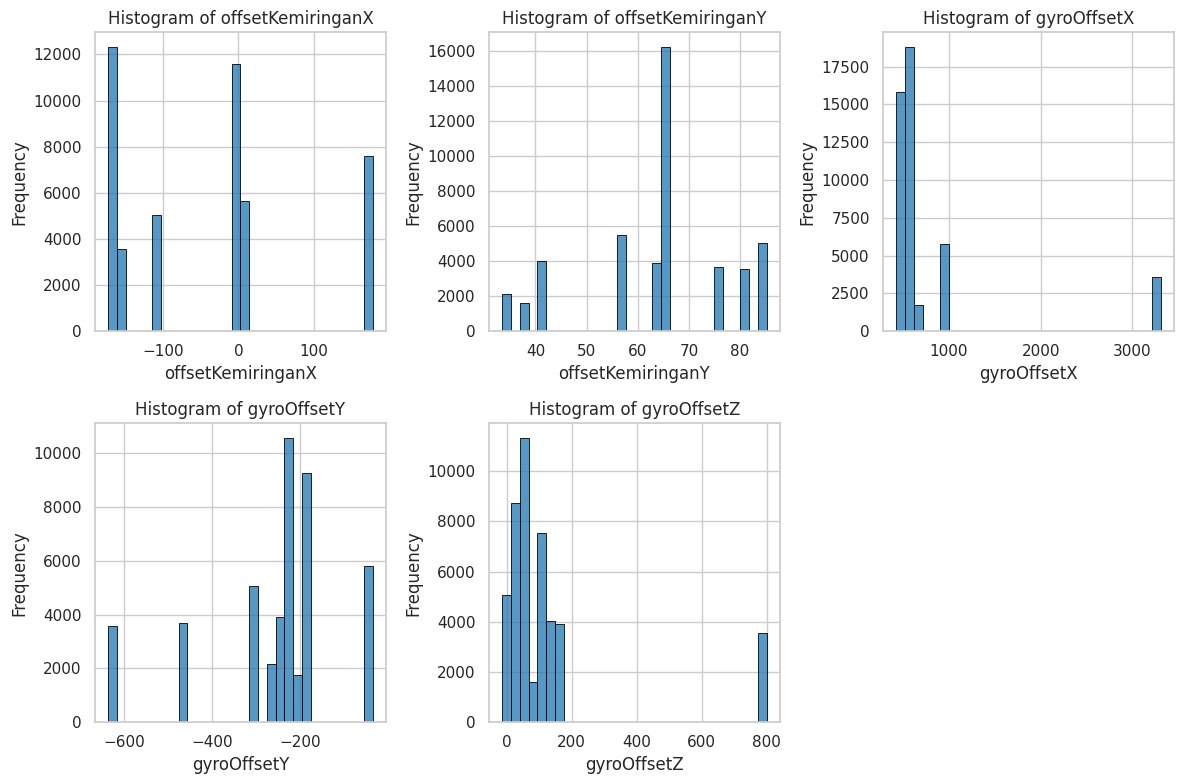

In [77]:
n_offsets = len(offset_columns)
n_columns_plot = 3
n_rows_plot = int((n_offsets + n_columns_plot - 1) / n_columns_plot)

fig, axes = plt.subplots(n_rows_plot, n_columns_plot, figsize=(4 * n_columns_plot, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(offset_columns):
    if col not in df_all.columns:
        continue
    sns.histplot(df_all[col], bins=30, ax=axes[i], kde=False, edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

We see that there is almost no distribution of offset values.

In [78]:
unique_counts = df_all[offset_columns].nunique()

for col in offset_columns:
    print(f"\n{col} ({unique_counts[col]} unique values):")
    print(sorted(df_all[col].unique()))


offsetKemiringanX (12 unique values):
[np.float64(-172.98), np.float64(-168.98), np.float64(-157.89), np.float64(-109.45), np.float64(-5.57), np.float64(-4.0), np.float64(0.56), np.float64(3.8), np.float64(4.35), np.float64(170.69), np.float64(174.4), np.float64(178.34)]

offsetKemiringanY (12 unique values):
[np.float64(33.48), np.float64(37.82), np.float64(40.47), np.float64(56.51), np.float64(64.47), np.float64(64.68), np.float64(65.25), np.float64(65.66), np.float64(66.07), np.float64(75.28), np.float64(81.21), np.float64(85.21)]

gyroOffsetX (12 unique values):
[np.float64(424.92), np.float64(512.02), np.float64(512.43), np.float64(514.03), np.float64(525.94), np.float64(566.03), np.float64(569.78), np.float64(579.51), np.float64(603.61), np.float64(654.43), np.float64(975.48), np.float64(3309.16)]

gyroOffsetY (12 unique values):
[np.float64(-636.78), np.float64(-464.58), np.float64(-297.81), np.float64(-265.2), np.float64(-247.19), np.float64(-233.62), np.float64(-220.87), np.f

Since the amount of unique values of offset is equal to the amount of data collection session (4). We cannot use offset as it is since it will cause major overfitting.

##### 3.3.2.5. Kemiringan Features Analysis

First we define all of the kemiringan features.

In [79]:
kemiringan_columns = ['kemiringanX', 'kemiringanY', 'rawKemiringanX', 'rawKemiringanY']

df_all[['kemiringanX', 'kemiringanY', 'rawKemiringanX', 'rawKemiringanY', 'offsetKemiringanX', 'offsetKemiringanY']].head()

,kemiringanX,kemiringanY,rawKemiringanX,rawKemiringanY,offsetKemiringanX,offsetKemiringanY
0,-3.83,-2.83,0.52,37.65,4.35,40.47
1,-1.34,-3.04,3.01,37.44,4.35,40.47
2,-2.57,-2.38,1.78,38.09,4.35,40.47
3,-5.51,-2.59,-1.16,37.88,4.35,40.47
4,-3.29,-0.62,1.06,39.85,4.35,40.47


First, `kemiringanX` and `kemiringanY` are the adjusted raw values using the offsets.

We can check the difference.

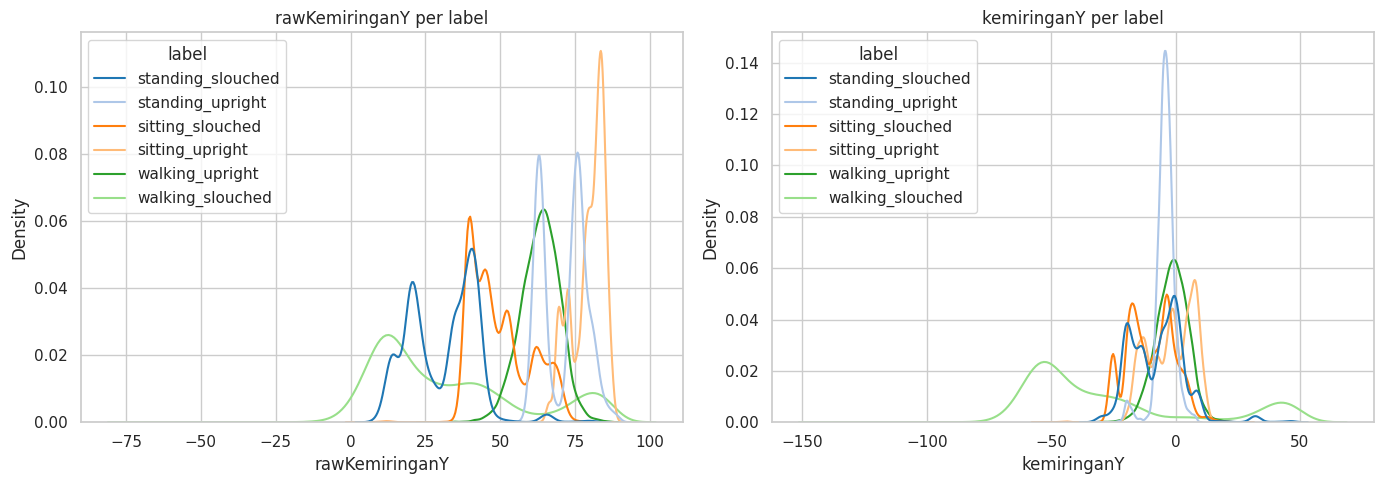

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_all, x='rawKemiringanY', hue='label', ax=axes[0], common_norm=False)
axes[0].set_title('rawKemiringanY per label')
axes[0].set_xlabel('rawKemiringanY')

sns.kdeplot(data=df_all, x='kemiringanY', hue='label', ax=axes[1], common_norm=False)
axes[1].set_title('kemiringanY per label')
axes[1].set_xlabel('kemiringanY')

plt.tight_layout()
plt.show()

We see that kemiringan is an important feature in determing the label.

We visualize the kemiringan of both X and Y.

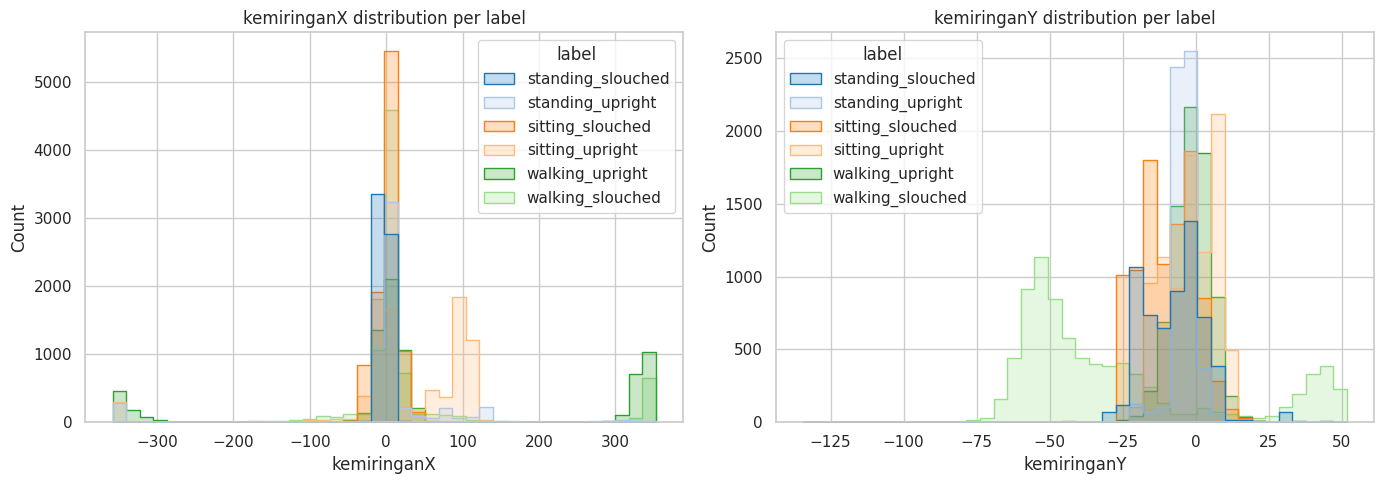

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_all, x='kemiringanX', hue='label', bins=40, element='step', stat='count', common_norm=False, ax=axes[0])
axes[0].set_title('kemiringanX distribution per label')
axes[0].set_xlabel('kemiringanX')
axes[0].set_ylabel('Count')

sns.histplot(data=df_all, x='kemiringanY', hue='label', bins=40, element='step', stat='count', common_norm=False, ax=axes[1])
axes[1].set_title('kemiringanY distribution per label')
axes[1].set_xlabel('kemiringanY')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

See that both `kemiringanY` and `kemiringanX` contain important information to determent the label.

We can also visualize the combined importance of both `kemiringanX` and `kemiringanY`

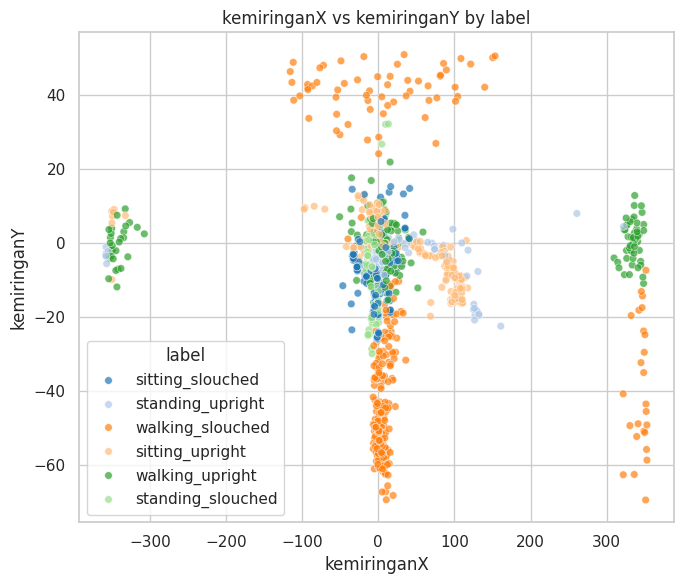

In [82]:
plot_df = df_all.sample(min(len(df_all), 1500), random_state=42)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x='kemiringanX', y='kemiringanY', hue='label', s=30, alpha=0.7)
plt.title('kemiringanX vs kemiringanY by label')
plt.xlabel('kemiringanX')
plt.ylabel('kemiringanY')
plt.tight_layout()
plt.show()

##### 3.3.2.6. Similar Features Analysis

There are multiple features which are composits.

Which include raw value, offset and the final values (after offset).

In [83]:
pairs_info = [
    {
        "group": "Tilt X",
        "raw": "rawKemiringanX",
        "offset": "offsetKemiringanX",
        "final": "kemiringanX",
        "formula": "final = raw - offset"
    },
    {
        "group": "Tilt Y",
        "raw": "rawKemiringanY",
        "offset": "offsetKemiringanY",
        "final": "kemiringanY",
        "formula": "final = raw - offset"
    },
    {
        "group": "Gyro X",
        "raw": "rawGyroX",
        "offset": "gyroOffsetX",
        "final": "kecepatanRotasiX",
        "formula": "final = (raw - offset) / 131"
    },
    {
        "group": "Gyro Y",
        "raw": "rawGyroY",
        "offset": "gyroOffsetY",
        "final": "kecepatanRotasiY",
        "formula": "final = (raw - offset) / 131"
    },
    {
        "group": "Gyro Z",
        "raw": "rawGyroZ",
        "offset": "gyroOffsetZ",
        "final": "kecepatanRotasiZ",
        "formula": "final = (raw - offset) / 131"
    }
]

pairing_df = pd.DataFrame(pairs_info)
pairing_df

,group,raw,offset,final,formula
0,Tilt X,rawKemiringanX,offsetKemiringanX,kemiringanX,final = raw - offset
1,Tilt Y,rawKemiringanY,offsetKemiringanY,kemiringanY,final = raw - offset
2,Gyro X,rawGyroX,gyroOffsetX,kecepatanRotasiX,final = (raw - offset) / 131
3,Gyro Y,rawGyroY,gyroOffsetY,kecepatanRotasiY,final = (raw - offset) / 131
4,Gyro Z,rawGyroZ,gyroOffsetZ,kecepatanRotasiZ,final = (raw - offset) / 131


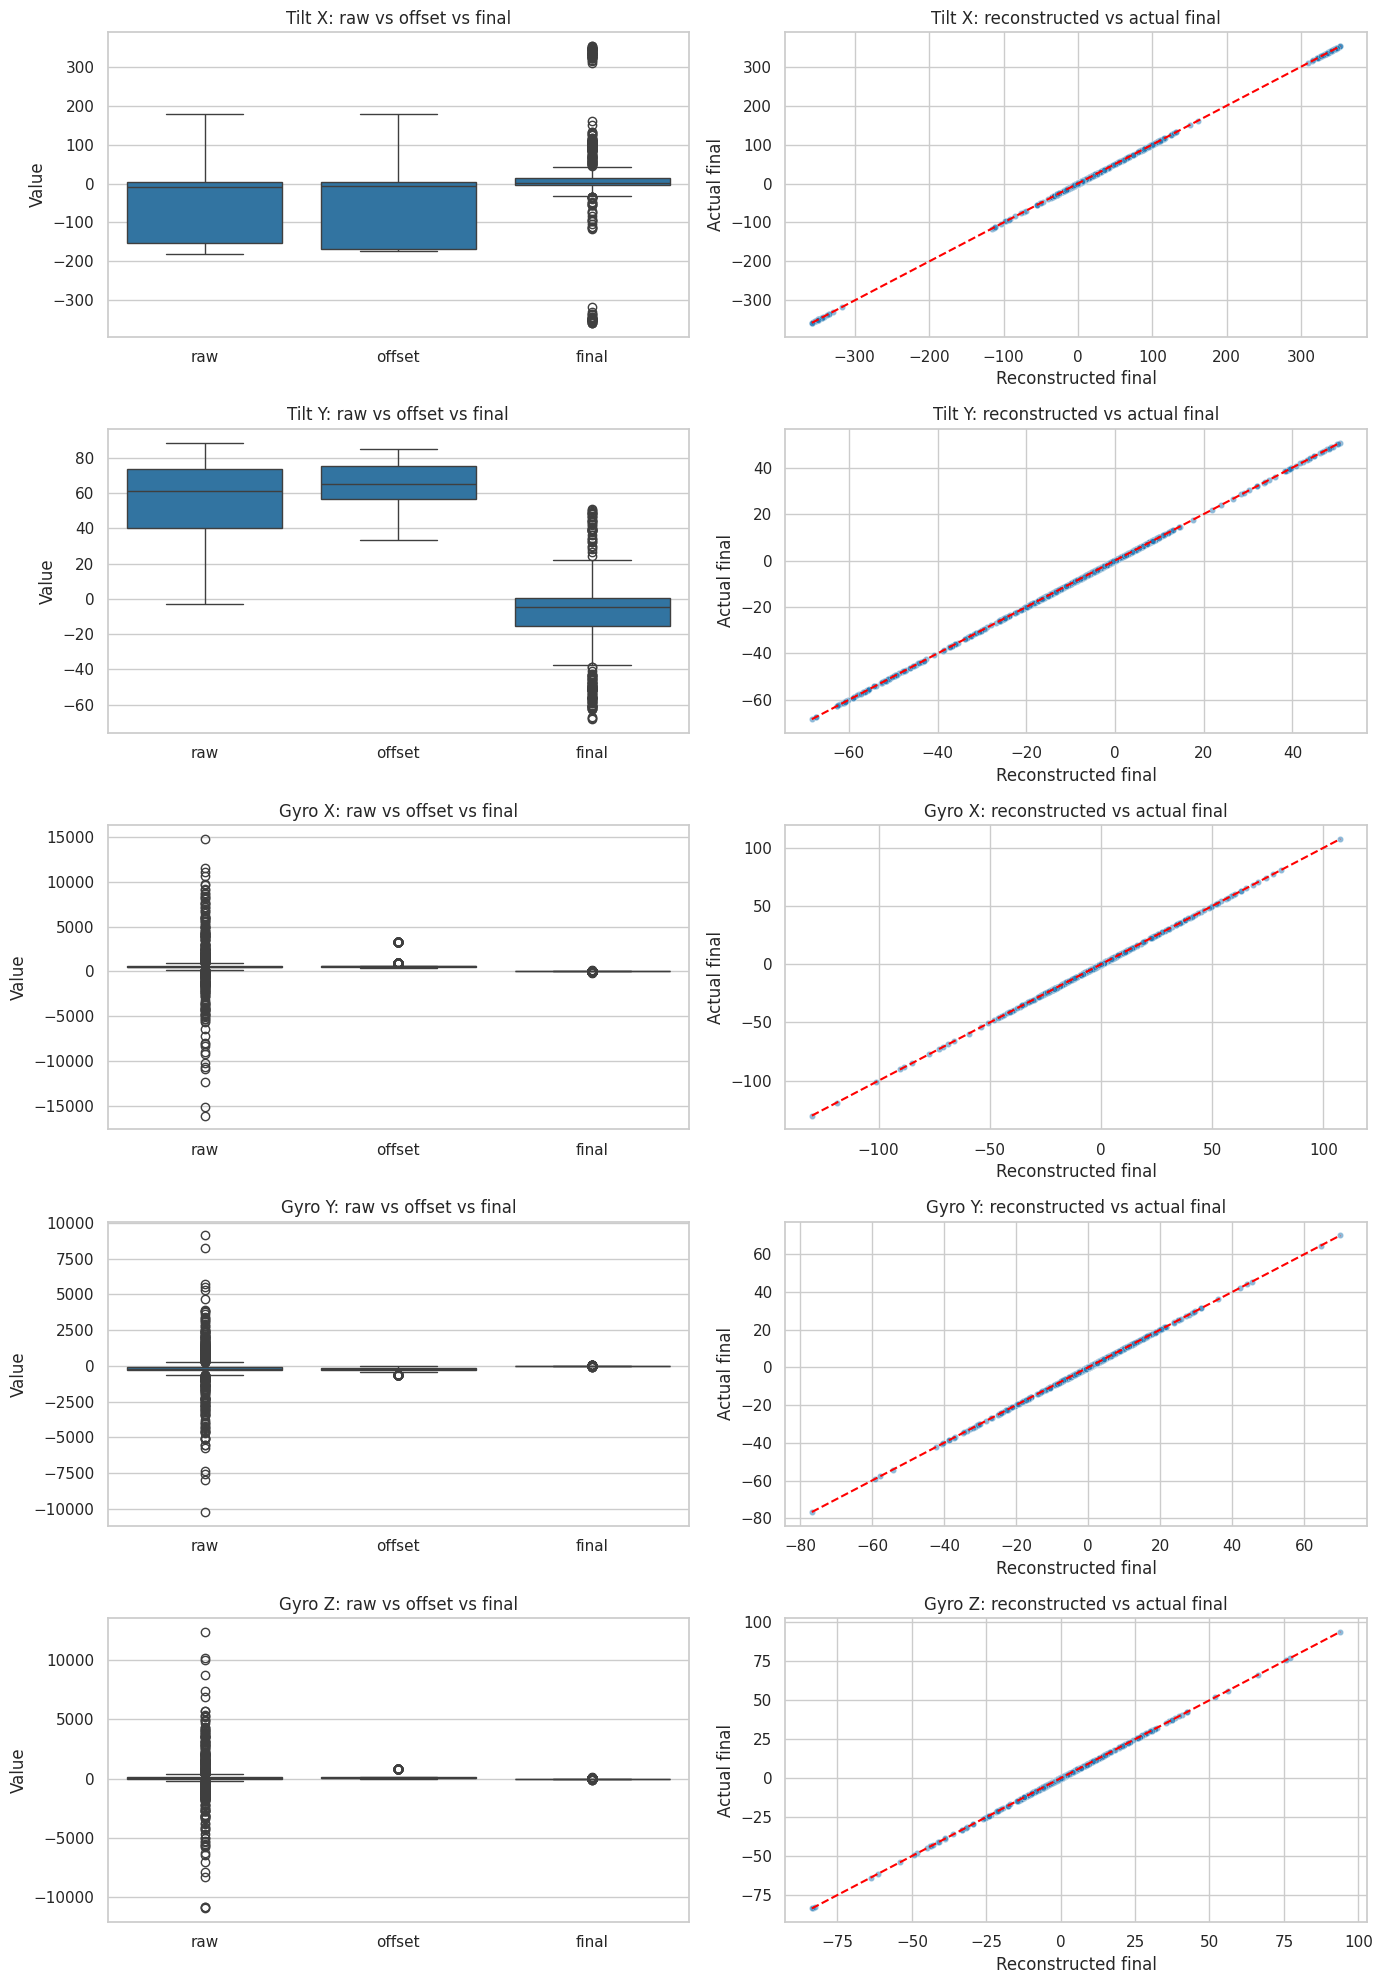

In [84]:
fig, axes = plt.subplots(len(pairs_info), 2, figsize=(14, 4 * len(pairs_info)))

sample_n = min(len(df_all), 1000)
plot_df = df_all.sample(sample_n, random_state=42).copy()

for i, item in enumerate(pairs_info):
    raw_col = item["raw"]
    offset_col = item["offset"]
    final_col = item["final"]
    group = item["group"]

    if "Tilt" in group:
        plot_df["reconstructed"] = plot_df[raw_col] - plot_df[offset_col]
    else:
        plot_df["reconstructed"] = (plot_df[raw_col] - plot_df[offset_col]) / 131.0

    long_df = pd.DataFrame({
        "raw": plot_df[raw_col],
        "offset": plot_df[offset_col],
        "final": plot_df[final_col]
    }).melt(var_name="type", value_name="value")

    sns.boxplot(data=long_df, x="type", y="value", ax=axes[i, 0])
    axes[i, 0].set_title(f"{group}: raw vs offset vs final")
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Value")

    sns.scatterplot(x=plot_df["reconstructed"], y=plot_df[final_col], s=20, alpha=0.5, ax=axes[i, 1])
    min_v = min(plot_df["reconstructed"].min(), plot_df[final_col].min())
    max_v = max(plot_df["reconstructed"].max(), plot_df[final_col].max())
    axes[i, 1].plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--")
    axes[i, 1].set_title(f"{group}: reconstructed vs actual final")
    axes[i, 1].set_xlabel("Reconstructed final")
    axes[i, 1].set_ylabel("Actual final")

plt.tight_layout()
plt.show()

The plot shows that raw, offset, and final are composit features. Thus we should only use one which is the final feature and drop the raw and offset to stop overfitting.

##### 3.3.2.7. Raw Acc Feature Analysis

In [85]:
df_all.columns

Index(['timestamp', 'rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY',
       'rawGyroZ', 'rawKemiringanX', 'rawKemiringanY', 'offsetKemiringanX',
       'offsetKemiringanY', 'kemiringanX', 'kemiringanY', 'gyroOffsetX',
       'gyroOffsetY', 'gyroOffsetZ', 'kecepatanRotasiX', 'kecepatanRotasiY',
       'kecepatanRotasiZ', 'label'],
      dtype='object')

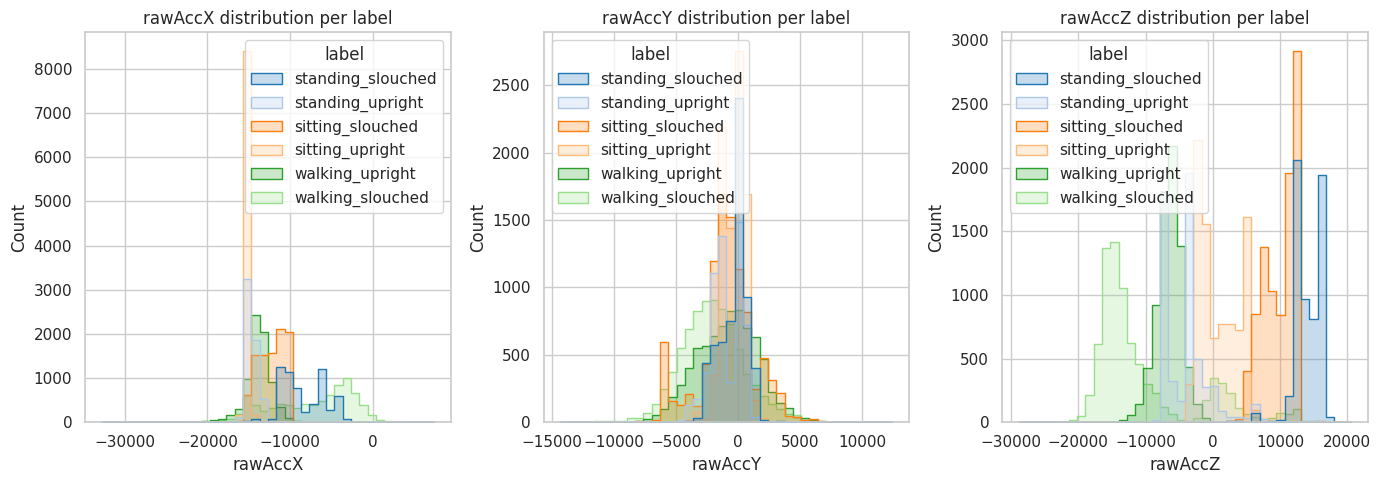

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.histplot(data=df_all, x='rawAccX', hue='label', bins=40, element='step', stat='count', common_norm=False, ax=axes[0])
axes[0].set_title('rawAccX distribution per label')
axes[0].set_xlabel('rawAccX')
axes[0].set_ylabel('Count')

sns.histplot(data=df_all, x='rawAccY', hue='label', bins=40, element='step', stat='count', common_norm=False, ax=axes[1])
axes[1].set_title('rawAccY distribution per label')
axes[1].set_xlabel('rawAccY')
axes[1].set_ylabel('Count')

sns.histplot(data=df_all, x='rawAccZ', hue='label', bins=40, element='step', stat='count', common_norm=False, ax=axes[2])
axes[2].set_title('rawAccZ distribution per label')
axes[2].set_xlabel('rawAccZ')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### 3.3.3 Categorical Distribution

In [87]:
categorical_columns.drop(label_column)

Index([], dtype='object')

There is no categorical data other than the label itself.

## 4 - Preprocessing

### 4.1. Dropping Columns

#### 4.1.1. Dropping Timestamp

Timestamp overfits label, since each label is takken on sessions.
Proven at EDA [here](#scrollTo=G1OO8iNIwgkM).

In [88]:
df_all = df_all.drop(columns=['timestamp'])

df_all.columns

Index(['rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY', 'rawGyroZ',
       'rawKemiringanX', 'rawKemiringanY', 'offsetKemiringanX',
       'offsetKemiringanY', 'kemiringanX', 'kemiringanY', 'gyroOffsetX',
       'gyroOffsetY', 'gyroOffsetZ', 'kecepatanRotasiX', 'kecepatanRotasiY',
       'kecepatanRotasiZ', 'label'],
      dtype='object')

#### 4.1.2. Dropping Offsets

There is no distribution of offset. It is constant for each label thus causing overfitting. Proven at EDA [here](#scrollTo=rIfK3EXeyeka).

In [89]:
offset_columns = ['offsetKemiringanX', 'offsetKemiringanY', 'gyroOffsetX', 'gyroOffsetY', 'gyroOffsetZ']
df_all = df_all.drop(columns=offset_columns)
df_all.columns

Index(['rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY', 'rawGyroZ',
       'rawKemiringanX', 'rawKemiringanY', 'kemiringanX', 'kemiringanY',
       'kecepatanRotasiX', 'kecepatanRotasiY', 'kecepatanRotasiZ', 'label'],
      dtype='object')

#### 4.1.3. Dropping Raw Kemiringan

There is no need to use both Kemiringan after offset and its raw value as it instead causes overfitting. Proven at EDA [here](#scrollTo=yXMd-zCP27HB).

In [90]:
df_all = df_all.drop(columns=['rawKemiringanX', 'rawKemiringanY'])
df_all.columns

Index(['rawAccX', 'rawAccY', 'rawAccZ', 'rawGyroX', 'rawGyroY', 'rawGyroZ',
       'kemiringanX', 'kemiringanY', 'kecepatanRotasiX', 'kecepatanRotasiY',
       'kecepatanRotasiZ', 'label'],
      dtype='object')

#### 4.1.4. Dropping Composit Features (raw vs offset vs final)

There is no need to use raw and offset since final is the result of raw and offset. Using those features together causes overfitting. Proven at EDA [here](#scrollTo=G0CU6T9WPl7R).

In [91]:
df_all = df_all.drop(columns=['rawGyroX', 'rawGyroY', 'rawGyroZ'])
df_all.columns

Index(['rawAccX', 'rawAccY', 'rawAccZ', 'kemiringanX', 'kemiringanY',
       'kecepatanRotasiX', 'kecepatanRotasiY', 'kecepatanRotasiZ', 'label'],
      dtype='object')

### 4.2. Adding Feature (from Feature Engineering)

Skipped

### 4.3. Normalize Data

Skipped

### 4.4. Deal with Missing Data

Skipped.

### 4.5. Encoding

#### 4.5.1 Label Encoding

In [92]:
label_encoder = LabelEncoder()
df_all["label_encoded"] = label_encoder.fit_transform(df_all["label"])

label_mapping = {
    label: int(code)
    for code, label in enumerate(label_encoder.classes_)
}

print(label_mapping)

df_all['label_encoded'].value_counts()

{'sitting_slouched': 0, 'sitting_upright': 1, 'standing_slouched': 2, 'standing_upright': 3, 'walking_slouched': 4, 'walking_upright': 5}


,count
label_encoded,
0,9434
1,8742
4,8163
5,7545
2,6161
3,5729


We can drop the categorical label.

In [93]:
df_all = df_all.drop(columns=['label'])

label_column = 'label_encoded'

In [94]:
df_all.columns

Index(['rawAccX', 'rawAccY', 'rawAccZ', 'kemiringanX', 'kemiringanY',
       'kecepatanRotasiX', 'kecepatanRotasiY', 'kecepatanRotasiZ',
       'label_encoded'],
      dtype='object')

## 5 - Split Data (train/test)

Split label and features data.

In [95]:
X = df_all.drop(columns=[label_column])
y = df_all[label_column]

Split train and test.

In [96]:
print("Split 80 train / 20 test")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42, stratify=y)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

print("\nLabel distribution (train):")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nLabel distribution (test):")
print(pd.Series(y_test).value_counts(normalize=True))

Split 80 train / 20 test
Train size: 36619
Test size : 9155

Label distribution (train):
label_encoded
0    0.206095
1    0.190994
4    0.178323
5    0.164832
2    0.134602
3    0.125154
Name: proportion, dtype: float64

Label distribution (test):
label_encoded
0    0.206117
1    0.190934
4    0.178372
5    0.164828
2    0.134571
3    0.125177
Name: proportion, dtype: float64


## 6 - Baseline Model

### 6.1. Create Base Fold to use for finding the best model
Using Stratified K-Fold since Drafted is imbalanced.

In [106]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 6.2. The Model Comparison

Comparing many models and the estimated model size.

#### 6.2.1. ML Models

##### 6.2.1.1. Training

In [125]:
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        loss_function='MultiClass',
        verbose=False
    ),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC(
            probability=True,
            random_state=42
        )
    )
}

In [126]:
results = []
fitted_models = {}

print(f"{'Model':<25} | {'Train F1-macro':<15} | {'Test F1':<10} | {'Std Dev':<10} | {'Size (kB)':<10}")
print("-" * 90)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
    mean_f1 = cv_scores.mean()
    std_f1 = cv_scores.std()

    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred_test, average='macro')

    with tempfile.NamedTemporaryFile(delete=False, suffix=".joblib") as tmp:
        tmp_path = tmp.name

    joblib.dump(model, tmp_path)
    size_bytes = os.path.getsize(tmp_path)
    os.remove(tmp_path)
    size_kb = size_bytes / 1024.0

    results.append({
        'Model': name,
        'Train_F1_macro_mean': mean_f1,
        'Train_F1_macro_std': std_f1,
        'Test_F1_macro': test_f1,
        'Model_size_bytes': size_bytes,
        'Model_size_kB': size_kb,
        'Type': 'ML'
    })

    fitted_models[name] = model

    print(f"{name:<25} | {mean_f1:<15.5f} | {test_f1:<10.5f} | {std_f1:<10.5f} | {size_kb:<10.1f}")

print("-" * 90)

ml_results_df = pd.DataFrame(results).sort_values(
    by=["Test_F1_macro"],
    ascending=False
)
ml_results_df

Model                     | Train F1-macro  | Test F1    | Std Dev    | Size (kB) 
------------------------------------------------------------------------------------------
Logistic Regression       | 0.85070         | 0.85742    | 0.00324    | 2.3       
Random Forest             | 0.98076         | 0.98407    | 0.00132    | 21773.9   
Extra Trees               | 0.98581         | 0.98760    | 0.00112    | 61391.1   
AdaBoost                  | 0.66925         | 0.76769    | 0.05783    | 39.3      
Gradient Boosting         | 0.97859         | 0.98155    | 0.00106    | 755.2     
XGBoost                   | 0.98827         | 0.99133    | 0.00123    | 1232.0    
LightGBM                  | 0.98852         | 0.99170    | 0.00054    | 2028.9    
CatBoost                  | 0.98555         | 0.98761    | 0.00034    | 3601.2    
SVM                       | 0.97376         | 0.97659    | 0.00176    | 648.7     
-------------------------------------------------------------------------------

,Model,Train_F1_macro_mean,Train_F1_macro_std,Test_F1_macro,Model_size_bytes,Model_size_kB,Type
6,LightGBM,0.988517,0.000540,0.991698,2077604,2028.910156,ML
5,XGBoost,0.988272,0.001231,0.991334,1261533,1231.965820,ML
7,CatBoost,0.985549,0.000341,0.987608,3687587,3601.159180,ML
2,Extra Trees,0.985813,0.001123,0.987604,62864489,61391.102539,ML
1,Random Forest,0.980759,0.001318,0.984070,22296521,21773.946289,ML
4,Gradient Boosting,0.978587,0.001057,0.981547,773353,755.227539,ML
8,SVM,0.973762,0.001758,0.976594,664261,648.692383,ML
0,Logistic Regression,0.850698,0.003236,0.857419,2377,2.321289,ML
3,AdaBoost,0.669246,0.057828,0.767692,40244,39.300781,ML


##### 6.2.1.2. Feature Importances

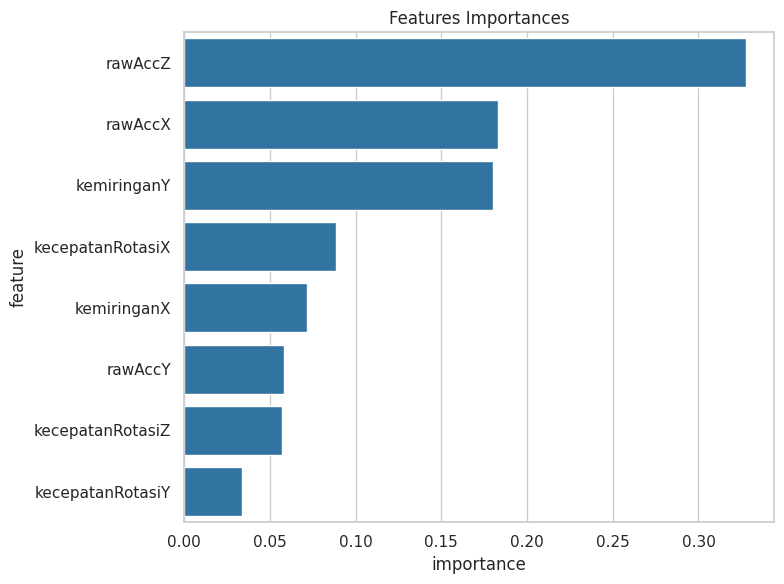

In [127]:
# Manualy change the model ~ e.g. 'Random Forest', 'CatBoost'
model_checked = fitted_models.get('Random Forest', None)

if isinstance(model_checked, Pipeline):
  rf_core = model_checked.named_steps[[k for k in model_checked.named_steps.keys() if 'forest' in k or 'random' in k][0]]
else:
  rf_core = model_checked

importances = rf_core.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance_df,
    x='importance',
    y='feature'
)
plt.title(f'Features Importances')
plt.tight_layout()
plt.show()

#### 6.2.2. Deep Learning Models

In [111]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
n_classes = y_train.nunique()

dl_results = []

def cross_val_f1_dl(build_fn, X, y, cv, epochs=50, batch_size=32, verbose=0, is_sequence=False):
    """
    Train a fresh DL model on each fold and compute macro F1 on the fold's validation split.
    Returns list of F1 scores across folds.
    """
    f1_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if is_sequence:
            X_tr_fold = X_tr.reshape(-1, n_features, 1)
            X_val_fold = X_val.reshape(-1, n_features, 1)
        else:
            X_tr_fold = X_tr
            X_val_fold = X_val

        model = build_fn()

        model.fit(X_tr_fold, y_tr.values, epochs=epochs, batch_size=batch_size, validation_data=(X_val_fold, y_val.values), verbose=verbose)

        y_val_proba = model.predict(X_val_fold, verbose=0)
        y_val_pred = y_val_proba.argmax(axis=1)

        f1_val = f1_score(y_val, y_val_pred, average='macro')
        f1_scores.append(f1_val)

    return np.array(f1_scores)

def train_and_evaluate_dl(
    model_name,
    build_fn,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    cv,
    epochs_cv=30,
    epochs_full=50,
    batch_size=32,
    is_sequence=False,
    verbose_cv=0,
    verbose_full=0
):
    f1_scores = cross_val_f1_dl(build_fn=build_fn, X=X_train_scaled, y=y_train, cv=cv, epochs=epochs_cv, batch_size=batch_size, verbose=verbose_cv, is_sequence=is_sequence)

    mean_f1 = f1_scores.mean()
    std_f1 = f1_scores.std()

    if is_sequence:
        X_train_full = X_train_scaled.reshape(-1, n_features, 1)
        X_test_full = X_test_scaled.reshape(-1, n_features, 1)
    else:
        X_train_full = X_train_scaled
        X_test_full = X_test_scaled

    model = build_fn()
    history = model.fit(
        X_train_full,
        y_train.values,
        epochs=epochs_full,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=verbose_full
    )

    y_pred_proba = model.predict(X_test_full, verbose=0)
    y_pred = y_pred_proba.argmax(axis=1)
    test_f1 = f1_score(y_test, y_pred, average='macro')

    os.makedirs("output", exist_ok=True)
    path = f"output/{model_name.replace(' ', '_').lower()}.keras"
    model.save(path)
    size_bytes = os.path.getsize(path)
    size_kb = size_bytes / 1024.0

    dl_results.append({
        "Model": model_name,
        "Train_F1_macro_mean": mean_f1,
        "Train_F1_macro_std": std_f1,
        "Test_F1_macro": test_f1,
        "Model_size_bytes": size_bytes,
        "Model_size_kB": size_kb,
        "Type": "DL"
    })

    print(
        f"{model_name:<25} | "
        f"Train F1-macro: {mean_f1:.4f} ± {std_f1:.4f} | "
        f"Test F1-macro: {test_f1:.4f} | "
        f"Size: {size_kb:.1f} kB"
    )

    return model, history


# FFNN small
def build_ffnn_small():
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense( 32, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.2),
        layers.Dense( 16, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# FFNN deep
def build_ffnn_deep():
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense( 64, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense( 32, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense( 16, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# RNN simple
def build_rnn_simple():
    model = keras.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.SimpleRNN( 32, activation="tanh", return_sequences=False, kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.2),
        layers.Dense( 16, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


print(f"{'DL Model':<25} | {'Train F1-macro (mean±std)':<30} | {'Test F1-macro':<15} | {'Size (kB)':<10}")
print("-" * 100)

# FFNN small
ffnn_small, history_small = train_and_evaluate_dl(
    model_name="FFNN small",
    build_fn=build_ffnn_small,
    X_train_scaled=X_train_scaled,
    y_train=y_train,
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    cv=skf,
    epochs_cv=30,
    epochs_full=50,
    batch_size=32,
    is_sequence=False
)

# FFNN deep
ffnn_deep, history_deep = train_and_evaluate_dl(
    model_name="FFNN deep",
    build_fn=build_ffnn_deep,
    X_train_scaled=X_train_scaled,
    y_train=y_train,
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    cv=skf,
    epochs_cv=30,
    epochs_full=50,
    batch_size=32,
    is_sequence=False
)

# RNN simple
rnn_simple, history_rnn = train_and_evaluate_dl(
    model_name="RNN simple",
    build_fn=build_rnn_simple,
    X_train_scaled=X_train_scaled,
    y_train=y_train,
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    cv=skf,
    epochs_cv=30,
    epochs_full=50,
    batch_size=32,
    is_sequence=True
)

print("-" * 100)

dl_results_df = pd.DataFrame(dl_results).sort_values(
    by=["Test_F1_macro"],
    ascending=False
)
dl_results_df

DL Model                  | Train F1-macro (mean±std)      | Test F1-macro   | Size (kB) 
----------------------------------------------------------------------------------------------------
FFNN small                | Train F1-macro: 0.9745 ± 0.0014 | Test F1-macro: 0.9793 | Size: 38.0 kB
FFNN deep                 | Train F1-macro: 0.9750 ± 0.0021 | Test F1-macro: 0.9799 | Size: 72.7 kB
RNN simple                | Train F1-macro: 0.9766 ± 0.0035 | Test F1-macro: 0.9822 | Size: 50.9 kB
----------------------------------------------------------------------------------------------------


,Model,Train_F1_macro_mean,Train_F1_macro_std,Test_F1_macro,Model_size_bytes,Model_size_kB,Type
2,RNN simple,0.976558,0.003495,0.982176,52100,50.878906,DL
1,FFNN deep,0.974960,0.002073,0.979934,74487,72.741211,DL
0,FFNN small,0.974485,0.001400,0.979318,38922,38.009766,DL


#### 6.2.3. Results

In [128]:
all_results_df = pd.concat([ml_results_df, dl_results_df], ignore_index=True).sort_values(by=["Test_F1_macro"], ascending=False)

all_results_df

,Model,Train_F1_macro_mean,Train_F1_macro_std,Test_F1_macro,Model_size_bytes,Model_size_kB,Type
0,LightGBM,0.988517,0.000540,0.991698,2077604,2028.910156,ML
1,XGBoost,0.988272,0.001231,0.991334,1261533,1231.965820,ML
2,CatBoost,0.985549,0.000341,0.987608,3687587,3601.159180,ML
3,Extra Trees,0.985813,0.001123,0.987604,62864489,61391.102539,ML
4,Random Forest,0.980759,0.001318,0.984070,22296521,21773.946289,ML
9,RNN simple,0.976558,0.003495,0.982176,52100,50.878906,DL
5,Gradient Boosting,0.978587,0.001057,0.981547,773353,755.227539,ML
10,FFNN deep,0.974960,0.002073,0.979934,74487,72.741211,DL
11,FFNN small,0.974485,0.001400,0.979318,38922,38.009766,DL
6,SVM,0.973762,0.001758,0.976594,664261,648.692383,ML


### 6.3. Base Fine Tuning

Skipped.

## 7 - Hypotheses & Feature Engineering

### 7.1. Feature Engineering

Skipped

### 7.2. Final Model

FYI: we add regulator since model shows overfitting

In [142]:
final_models = {}

target_names = list(label_encoder.classes_)
feature_cols = list(X_train.columns)

def evaluate_and_store_model(model_name, model, X_train, y_train, X_test, y_test, feature_cols, target_names, final_models):
    model.fit(X_train, y_train)
    final_models[model_name] = model

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')

    print(f"Model: {model_name}")
    print(f"Train F1-macro: {train_f1:.4f}")
    print(f"Test  F1-macro: {test_f1:.4f}")
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    if hasattr(model, "feature_importances_"):
        fi = pd.DataFrame({
            "feature": feature_cols,
            "importance": model.feature_importances_
        }).sort_values(by="importance", ascending=False)

        display(fi)

        plt.figure(figsize=(7, 5))
        sns.barplot(data=fi, x="importance", y="feature")
        plt.title(f'Feature Importance - {model_name}')
        plt.tight_layout()
        plt.show()
    else:
        print(f"{model_name} does not expose feature_importances_ directly.")

    return train_f1, test_f1

#### 7.2.1. LightBGM

Model: LightGBM
Train F1-macro: 0.9842
Test  F1-macro: 0.9813

Classification Report (Test):
                   precision    recall  f1-score   support

 sitting_slouched       1.00      1.00      1.00      1887
  sitting_upright       0.99      1.00      0.99      1748
standing_slouched       0.98      0.99      0.98      1232
 standing_upright       0.99      0.98      0.98      1146
 walking_slouched       0.98      0.95      0.96      1633
  walking_upright       0.95      0.98      0.97      1509

         accuracy                           0.98      9155
        macro avg       0.98      0.98      0.98      9155
     weighted avg       0.98      0.98      0.98      9155



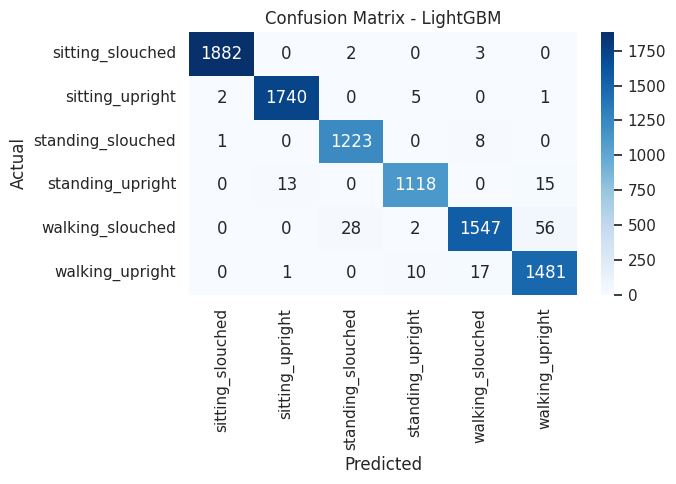

,feature,importance
2,rawAccZ,1047
4,kemiringanY,931
3,kemiringanX,655
0,rawAccX,470
1,rawAccY,411
5,kecepatanRotasiX,268
7,kecepatanRotasiZ,254
6,kecepatanRotasiY,162


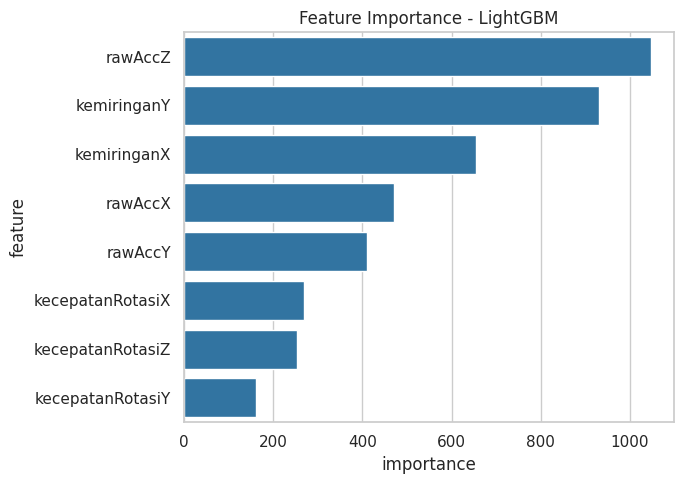

(0.9842084690663659, 0.9813300129228301)

In [143]:
lightgbm_final = LGBMClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

evaluate_and_store_model(
    model_name="LightGBM",
    model=lightgbm_final,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    feature_cols=feature_cols,
    target_names=target_names,
    final_models=final_models
)

## 7.3. Model Summary

In [144]:
summary_rows = []

for model_name, model in final_models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    summary_rows.append({
        "Model": model_name,
        "Train_F1_macro": f1_score(y_train, y_pred_train, average='macro'),
        "Test_F1_macro": f1_score(y_test, y_pred_test, average='macro')
    })

final_summary_df = pd.DataFrame(summary_rows).sort_values(by="Test_F1_macro", ascending=False)
display(final_summary_df)

,Model,Train_F1_macro,Test_F1_macro
0,LightGBM,0.984208,0.98133


## 8 - Export Model

Export model as C header to embbed in ESP.

In [145]:
all_export_results = []

# optional skip config per package
# example:
# skip_export_map = {
#     "emlearn": {"LightGBM", "XGBoost"},
#     "micromlgen": {"LightGBM", "XGBoost", "GradientBoosting"}
# }
skip_export_map = {
    "emlearn": set(),
    "micromlgen": set(),
    "m2cgen": set()
}

def append_export_result(
    results_container,
    package_name,
    model_name,
    exported,
    path=None,
    error=None
):
    header_size_bytes = None
    header_size_kb = None
    header_size_mb = None

    if exported and path is not None and os.path.exists(path):
        header_size_bytes = os.path.getsize(path)
        header_size_kb = round(header_size_bytes / 1024.0, 2)
        header_size_mb = round(header_size_bytes / (1024.0 * 1024.0), 4)

    results_container.append({
        "Package": package_name,
        "Model": model_name,
        "Exported": exported,
        "Path": str(path) if path is not None else None,
        "Header_size_bytes": header_size_bytes,
        "Header_size_kB": header_size_kb,
        "Header_size_MB": header_size_mb,
        "Error": None if exported else str(error)
    })

## 8.1. Package emlearn

Warning: Not all model are supported instantly by emlearn.

To see the suported models:   
https://emlearn.readthedocs.io/en/latest/source/README.html#platform-support

In [146]:
package_name = "emlearn"
output_dir = Path("output") / package_name
output_dir.mkdir(parents=True, exist_ok=True)

for model_name, model in final_models.items():
    if model_name in skip_export_map.get(package_name, set()):
        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=False,
            path=None,
            error="Skipped by user config"
        )
        continue

    try:
        # you can change method='loadable'
        cmodel = emlearn.convert(model)
        header_path = output_dir / f"{model_name.lower()}_model.h"
        cmodel.save(file=str(header_path), name=f"{model_name.lower()}_model")

        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=True,
            path=header_path
        )

    except Exception as e:
        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=False,
            path=None,
            error=e
        )

emlearn_results_df = pd.DataFrame([
    r for r in all_export_results if r["Package"] == package_name
]).sort_values(
    by=["Exported", "Header_size_bytes"],
    ascending=[False, True],
    na_position="last"
).reset_index(drop=True)

display(emlearn_results_df)

,Package,Model,Exported,Path,Header_size_bytes,Header_size_kB,Header_size_MB,Error
0,emlearn,LightGBM,False,None,None,None,None,Unknown model type: 'LGBMClassifier'


## 8.2. Package micromlgen

In [147]:
package_name = "micromlgen"
output_dir = Path("output") / package_name
output_dir.mkdir(parents=True, exist_ok=True)

# optional classmap
classmap = {
    int(code): label
    for label, code in label_mapping.items()
}

for model_name, model in final_models.items():
    if model_name in skip_export_map.get(package_name, set()):
        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=False,
            path=None,
            error="Skipped by user config"
        )
        continue

    try:
        c_code = port(model, classmap=classmap)
        header_path = output_dir / f"{model_name.lower()}_model.h"

        with open(header_path, "w", encoding="utf-8") as f:
            f.write(c_code)

        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=True,
            path=header_path
        )

    except Exception as e:
        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=False,
            path=None,
            error=e
        )

micromlgen_results_df = pd.DataFrame([
    r for r in all_export_results if r["Package"] == package_name
]).sort_values(
    by=["Exported", "Header_size_bytes"],
    ascending=[False, True],
    na_position="last"
).reset_index(drop=True)

display(micromlgen_results_df)

,Package,Model,Exported,Path,Header_size_bytes,Header_size_kB,Header_size_MB,Error
0,micromlgen,LightGBM,False,None,None,None,None,"clf MUST be one of SVC, OneClassSVM, RVC, SEFR..."


## 8.3. Package m2cgen

In [148]:
package_name = "m2cgen"
output_dir = Path("output") / package_name
output_dir.mkdir(parents=True, exist_ok=True)

for model_name, model in final_models.items():
    if model_name in skip_export_map.get(package_name, set()):
        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=False,
            path=None,
            error="Skipped by user config"
        )
        continue

    try:
        c_code = m2c.export_to_c(model)

        header_path = output_dir / f"{model_name.lower()}_model.h"

        with open(header_path, "w", encoding="utf-8") as f:
            f.write(c_code)

        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=True,
            path=header_path
        )

    except Exception as e:
        append_export_result(
            results_container=all_export_results,
            package_name=package_name,
            model_name=model_name,
            exported=False,
            path=None,
            error=e
        )

m2cgen_results_df = pd.DataFrame([
    r for r in all_export_results if r["Package"] == package_name
]).sort_values(
    by=["Exported", "Header_size_bytes"],
    ascending=[False, True],
    na_position="last"
).reset_index(drop=True)

display(m2cgen_results_df)

,Package,Model,Exported,Path,Header_size_bytes,Header_size_kB,Header_size_MB,Error
0,m2cgen,LightGBM,True,output/m2cgen/lightgbm_model.h,599014,584.97,0.5713,None


## 8.4. Summary

In [149]:
all_export_results_df = pd.DataFrame(all_export_results)

all_export_results_df = all_export_results_df.sort_values(
    by=["Model", "Exported", "Header_size_bytes"],
    ascending=[True, False, True],
    na_position="last"
).reset_index(drop=True)

display(all_export_results_df)

,Package,Model,Exported,Path,Header_size_bytes,Header_size_kB,Header_size_MB,Error
0,m2cgen,LightGBM,True,output/m2cgen/lightgbm_model.h,599014.0,584.97,0.5713,None
1,emlearn,LightGBM,False,None,NaN,NaN,NaN,Unknown model type: 'LGBMClassifier'
2,micromlgen,LightGBM,False,None,NaN,NaN,NaN,"clf MUST be one of SVC, OneClassSVM, RVC, SEFR..."
